In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Kernel density estimation

### 1D

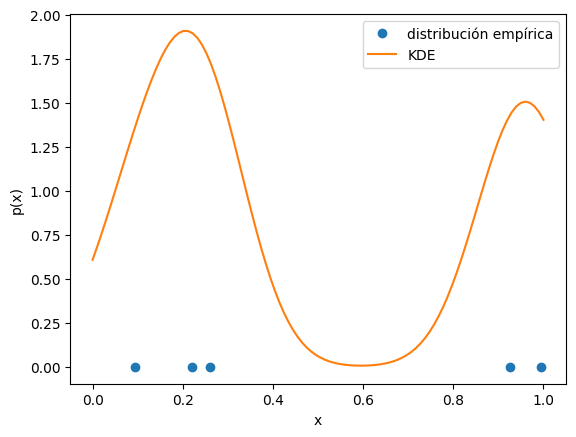

In [2]:
data = np.random.rand(5)

def gaussian_kernel(x, xi, bandwidth):
    return np.exp(-0.5 * ((x - xi) / bandwidth) ** 2) / (np.sqrt(2 * np.pi) * bandwidth)

def kde(data, x_grid, bandwidth=0.1):
    return np.mean([gaussian_kernel(x_grid, xi, bandwidth) for xi in data], axis=0)

# Distribución empírica:
plt.plot(data, np.zeros_like(data), 'o', label='distribución empírica')

# Densidad KDE:
x = np.linspace(0, 1, 100)
density = kde(data, x)
plt.plot(x, density, label='KDE')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend(loc='upper right')
plt.show()

## 2D

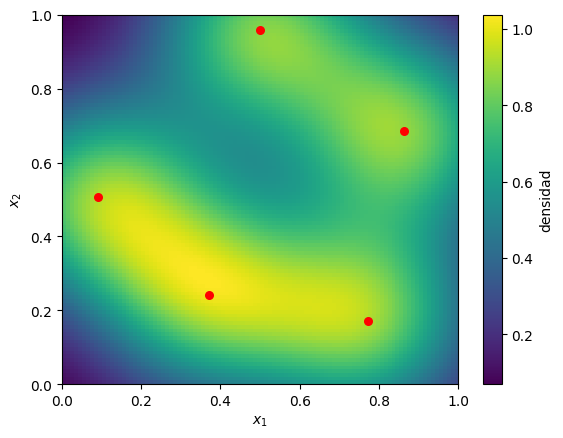

In [3]:
def gaussian_kernel(x, y, xi, yi, bandwidth):
    return np.exp(-0.5 * (((x - xi) ** 2 + (y - yi) ** 2) / bandwidth ** 2)) / (2 * np.pi * bandwidth ** 2)

def kde(data, x_grid, y_grid, bandwidth=0.2):
    density = np.zeros_like(x_grid, dtype=float)
    for xi, yi in zip(data[0], data[1]):
        density += gaussian_kernel(x_grid, y_grid, xi, yi, bandwidth)
    return density / len(data[0])

data = np.random.rand(2, 5)

x_grid, y_grid = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
density = kde(data, x_grid, y_grid)

plt.imshow(density, origin='lower', extent=[0, 1, 0, 1], cmap='viridis', aspect='auto')
plt.colorbar(label='densidad')
plt.scatter(data[0], data[1], c='red', s=30)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.show()